In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np

# **1. Load data**

In [2]:
df = pd.read_excel('data/raw/Online Retail.xlsx')
print("Load datasets successfully!!!")

Load datasets successfully!!!


## **1.1. Information basic data**

In [3]:
df.shape

(541909, 8)

In [4]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [5]:
df.tail(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541899,581587,22726,ALARM CLOCK BAKELIKE GREEN,4,2011-12-09 12:50:00,3.75,12680.0,France
541900,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,2011-12-09 12:50:00,3.75,12680.0,France
541901,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8,2011-12-09 12:50:00,1.95,12680.0,France
541902,581587,22629,SPACEBOY LUNCH BOX,12,2011-12-09 12:50:00,1.95,12680.0,France
541903,581587,23256,CHILDRENS CUTLERY SPACEBOY,4,2011-12-09 12:50:00,4.15,12680.0,France
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


## **1.2. Check basic data**

In [7]:
missing_value = df.isnull().sum()
missing_value.sort_index()

Country             0
CustomerID     135080
Description      1454
InvoiceDate         0
InvoiceNo           0
Quantity            0
StockCode           0
UnitPrice           0
dtype: int64

In [8]:
duplicate_value = df.duplicated().sum()
duplicate_value

5268

## **1.3. Check variables data**

### ***Variable Country***

In [9]:
country_var = df['Country'].value_counts().sort_index()
print(f"Variable Country: \n{country_var}")

Variable Country: 
Country
Australia                 1259
Austria                    401
Bahrain                     19
Belgium                   2069
Brazil                      32
Canada                     151
Channel Islands            758
Cyprus                     622
Czech Republic              30
Denmark                    389
EIRE                      8196
European Community          61
Finland                    695
France                    8557
Germany                   9495
Greece                     146
Hong Kong                  288
Iceland                    182
Israel                     297
Italy                      803
Japan                      358
Lebanon                     45
Lithuania                   35
Malta                      127
Netherlands               2371
Norway                    1086
Poland                     341
Portugal                  1519
RSA                         58
Saudi Arabia                10
Singapore                  229
Spain       

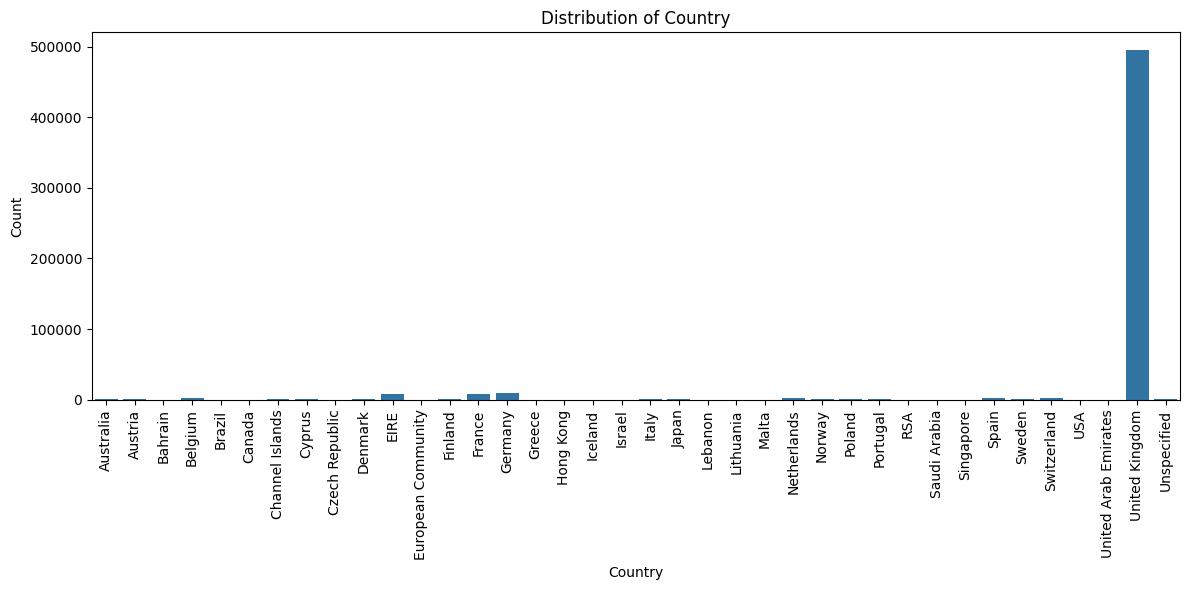

In [10]:
plt.figure(figsize=(12,6))
sns.barplot(x=country_var.index, y=country_var.values)
plt.xticks(rotation=90)
plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Distribution of Country')
plt.tight_layout()
plt.show()

In [11]:
# Country with the hights purchases 
max_country = country_var.idxmax()
max_value = country_var.max()

print(f"Country with the hights purchases: {max_country} ({max_value})")

Country with the hights purchases: United Kingdom (495478)


In [12]:
# Country with the lowest purchases 
min_country = country_var.idxmin()
min_value = country_var.min()

print(f"Country with the lowest purchases: {min_country} ({min_value})")

Country with the lowest purchases: Saudi Arabia (10)


### ***Variable Description***

In [13]:
description_var = df['Description'].value_counts()
print(f"Description values: \n{description_var}")

Description values: 
Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
                                      ... 
LETTER "U" BLING KEY RING                1
wet                                      1
wet boxes                                1
????damages????                          1
lost                                     1
Name: count, Length: 4223, dtype: int64


### ***Variable Quantity***

In [14]:
quantity_var = df['Quantity'].value_counts().sort_index()
quantity_var

Quantity
-80995    1
-74215    1
-9600     2
-9360     1
-9058     1
         ..
 4800     1
 5568     1
 12540    1
 74215    1
 80995    1
Name: count, Length: 722, dtype: int64

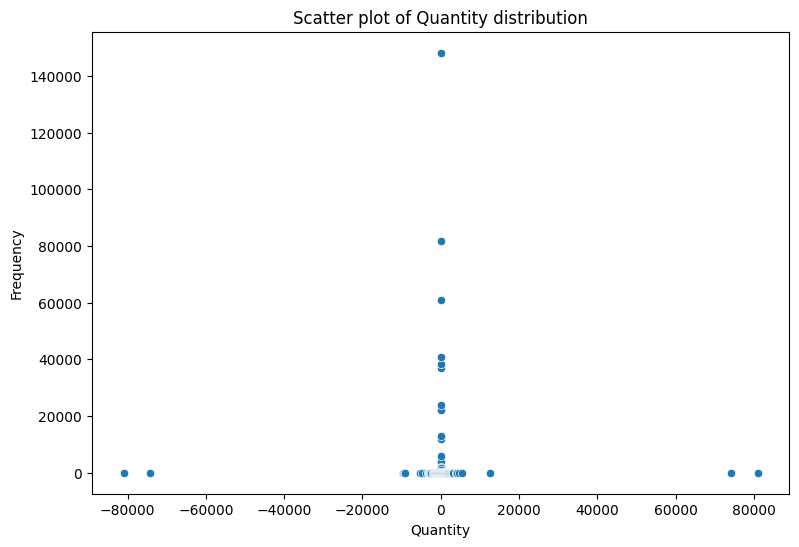

In [15]:
plt.figure(figsize=(9,6))
sns.scatterplot(x=quantity_var.index, y=quantity_var.values)

plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.title("Scatter plot of Quantity distribution")
plt.show()

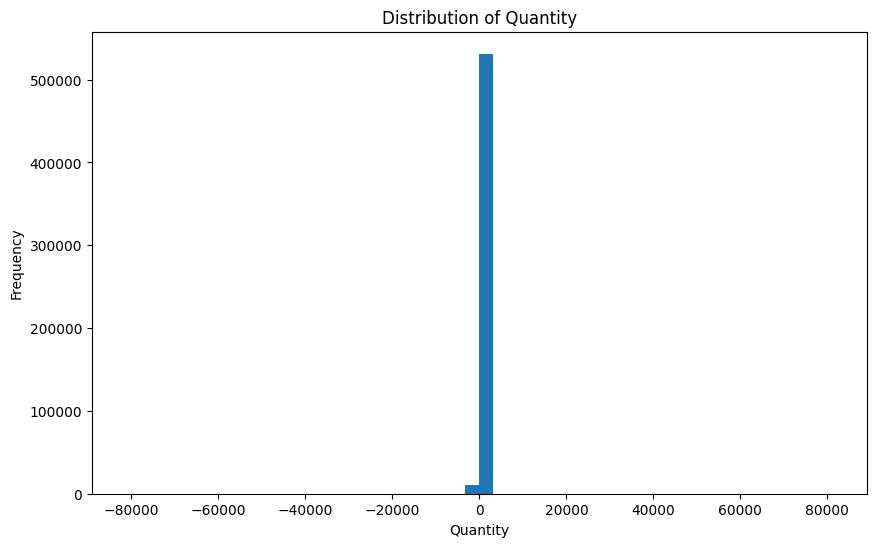

In [16]:
plt.figure(figsize=(10,6))
plt.hist(df['Quantity'], bins=50)
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.title('Distribution of Quantity')
plt.show()

### ***Variable UnitPrice***

In [17]:
unit_price_var = df['UnitPrice'].value_counts()
unit_price_var

UnitPrice
1.25       50496
1.65       38181
0.85       28497
2.95       27768
0.42       24533
           ...  
11.25          1
938.59         1
933.17         1
1714.17        1
224.69         1
Name: count, Length: 1630, dtype: int64

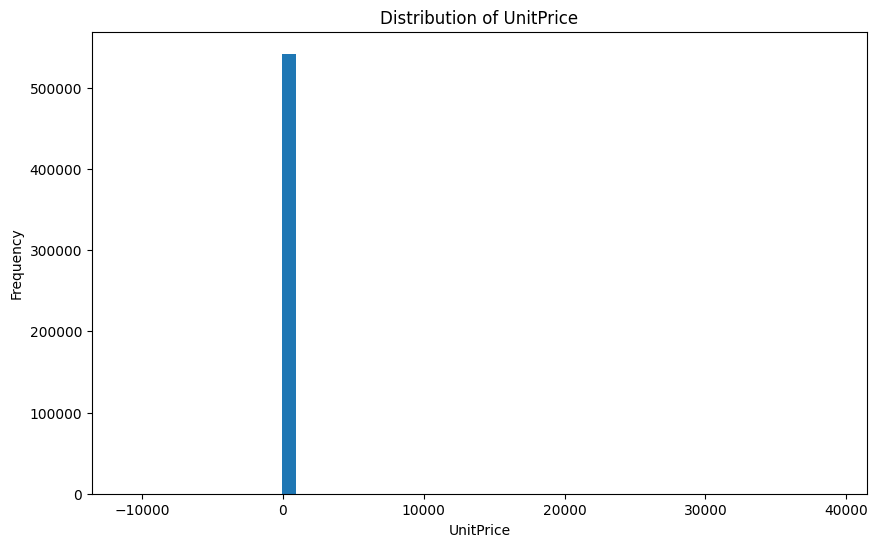

In [18]:
plt.figure(figsize=(10,6))
plt.hist(df['UnitPrice'], bins=50)
plt.xlabel('UnitPrice')
plt.ylabel('Frequency')
plt.title('Distribution of UnitPrice')
plt.show()